In [1]:
import sys

sys.path.append("..")

import pandas as pd 
import numpy as np
import seaborn as sns

from sklearn.model_selection import train_test_split , RandomizedSearchCV , KFold ,cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer 
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression , Lasso , Ridge , ElasticNet
from sklearn.ensemble import RandomForestRegressor , GradientBoostingRegressor



from src.data.cleaning import (
    clean_dataset
)

from src.features.engineering import (
    create_features
)

In [2]:
DATA_PATH='../data/raw/car details v4.csv'

df=pd.read_csv(DATA_PATH)
df=clean_dataset(df)
df=create_features(df)
df=df.drop(columns=['torque','engine','max_power'])

## Seprating Target


In [3]:
X=df.drop(columns='selling_price')
y=df['selling_price']

## Train Test Split

In [4]:
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
    )

## Identifying Numerical and Categorical Fetaures

In [5]:
numeric_features= X_train.select_dtypes(
    include="number"
).columns.tolist()
categorical_features= X_train.select_dtypes(
    exclude="number"
).columns.tolist()


print("Numeric:", numeric_features)
print("Categorical:", categorical_features)

Numeric: ['year', 'km_driven', 'mileage', 'seats', 'engine_cc', 'max_power_bhp', 'torque_nm', 'torque_rpm_min', 'torque_rpm_max', 'vehicle_age', 'km_per_year', 'power_per_cc']
Categorical: ['fuel', 'seller_type', 'transmission', 'owner', 'brand']


In [6]:
numeric_pipeline=Pipeline([
    ( 
        'imputer',
        SimpleImputer(strategy='median')
    ),(
        'scaler',
        StandardScaler()
    )
])

In [7]:
categorical_pipeline=Pipeline([
    (
        'imputer',
        SimpleImputer(strategy='most_frequent')
    ),
    (
        'encoder',
        OneHotEncoder(
            handle_unknown='ignore',
            sparse_output=True
        )
    )
])

In [8]:
preprocessor=ColumnTransformer(
    transformers=[
        ('numeric',
        numeric_pipeline,
        numeric_features),
        (
            'categorical',
            categorical_pipeline,
            categorical_features
        )
    ]
)

In [9]:
baseline_model=Pipeline([
    ('preprocessor',preprocessor),
    ('Linear Regression',LinearRegression())
])

In [10]:
ridge_model=Pipeline([
    ('preprocessor',preprocessor),
    ('Ridge',Ridge(alpha=10.0))
])

In [11]:
lasso_model=Pipeline([
    ('preprocessor',preprocessor),
    ('Lasso',Lasso(alpha=0.001,max_iter=10000))
])

In [12]:
elastic_model=Pipeline([
    ('preprocessor',preprocessor),
    ("Elastic",ElasticNet(
        alpha=0.001,
        l1_ratio=0.5,
        max_iter=10000,
))
])

In [13]:
rf_model=Pipeline([
    ('preprocessor',preprocessor),
    ('model',RandomForestRegressor(
       n_estimators= 500,
       min_samples_split= 5,
       min_samples_leaf= 1, 
       max_features= 1.0,
       max_depth= None,
        random_state=42,
        n_jobs=-1
    ))
])

In [14]:
# # Random forest hyperparameters tuning 
# param_distributions = {
#     "model__n_estimators": [200, 300, 500, 700],
#     "model__max_depth": [None, 10, 15, 20, 30],
#     "model__min_samples_split": [2, 5, 10],
#     "model__min_samples_leaf": [1, 2, 4],
#     "model__max_features": [1.0, "sqrt", "log2"],
# }
# search = RandomizedSearchCV(
#     estimator=rf_model,
#     param_distributions=param_distributions,
#     n_iter=20,
#     scoring="neg_root_mean_squared_error",
#     cv=5,
#     random_state=42,
#     n_jobs=-1,
#     verbose=1,
# )

In [15]:

# search.fit(X_train, y_train)

In [16]:
# print(search.best_params_)
# print(search.best_score_)

In [17]:
# best_rf=search.best_estimator_

In [18]:
gboosting_model=Pipeline([
    ('preprocessor',preprocessor),
    ('Gradeint Boosting',GradientBoostingRegressor(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=3,
            random_state=42,
    ))
])

In [19]:
# Baseline Model
y_log=np.log1p(y_train)
baseline_model.fit(X_train,y_log)

# Ridge Model
ridge_model.fit(X_train,y_log)

# Lasso Model
lasso_model.fit(X_train,y_log)

# Elastic Model
elastic_model.fit(X_train,y_log)

# Random Forest
rf_model.fit(X_train,y_train)

# Gradeint Boosting
gboosting_model.fit(X_train,y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('Gradeint Boosting', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](17,)","['year','km_driven','fuel',...,'km_per_year','power_per_cc','brand']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,17
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. T

In [20]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
import matplotlib.pyplot as plt


Linear Regression
MAE:  86,389.26
RMSE: 156,802.81
R²:   0.8879

Residual statistics:
count    1.386000e+03
mean     1.681173e+04
std      1.559552e+05
min     -1.092037e+06
25%     -4.745255e+04
50%      1.736507e+03
75%      6.899656e+04
max      2.943515e+06
Name: selling_price, dtype: float64


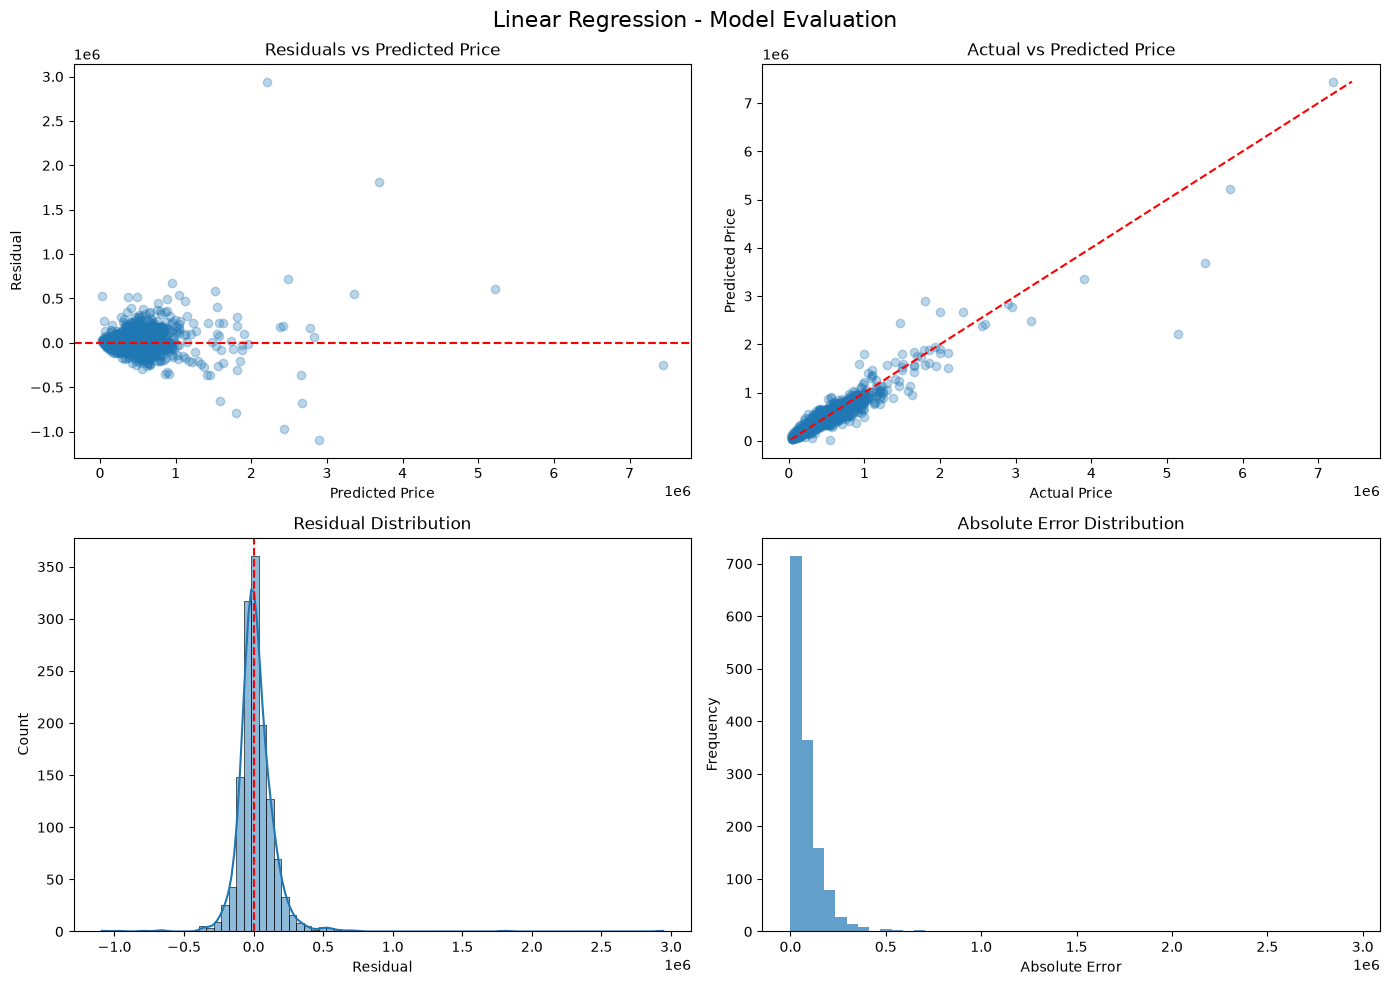


Ridge Regression
MAE:  88,394.88
RMSE: 165,629.86
R²:   0.8749

Residual statistics:
count    1.386000e+03
mean     1.828254e+04
std      1.646772e+05
min     -1.247280e+06
25%     -4.755923e+04
50%      1.700698e+03
75%      7.078721e+04
max      2.845957e+06
Name: selling_price, dtype: float64


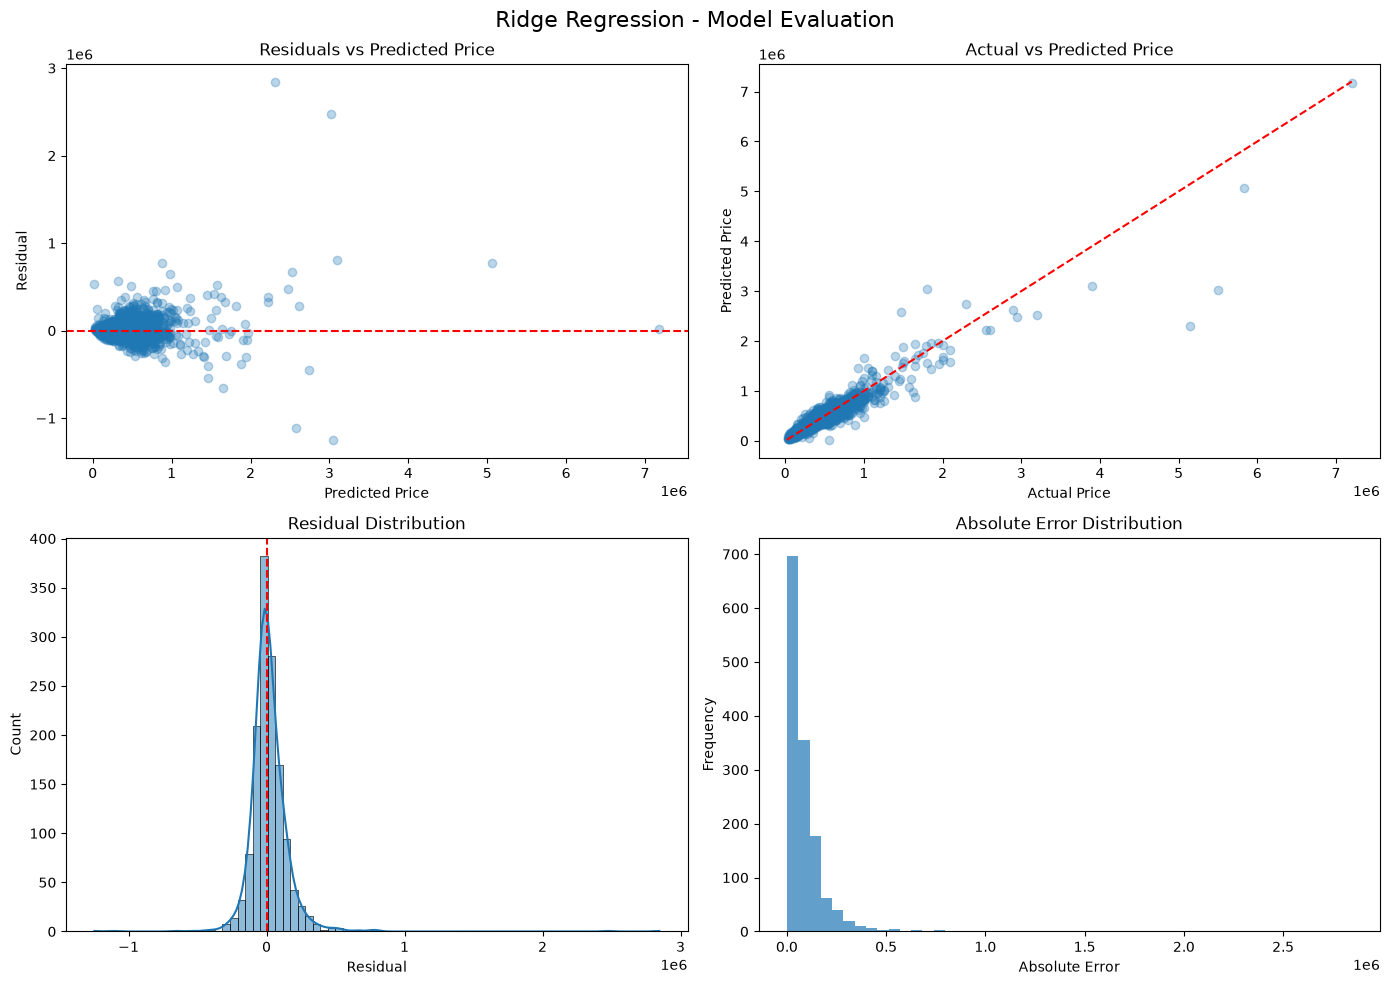


Lasso Regression
MAE:  90,636.97
RMSE: 173,744.77
R²:   0.8624

Residual statistics:
count    1.386000e+03
mean     1.932682e+04
std      1.727288e+05
min     -1.283983e+06
25%     -4.809000e+04
50%      3.873142e+02
75%      6.963733e+04
max      2.864744e+06
Name: selling_price, dtype: float64


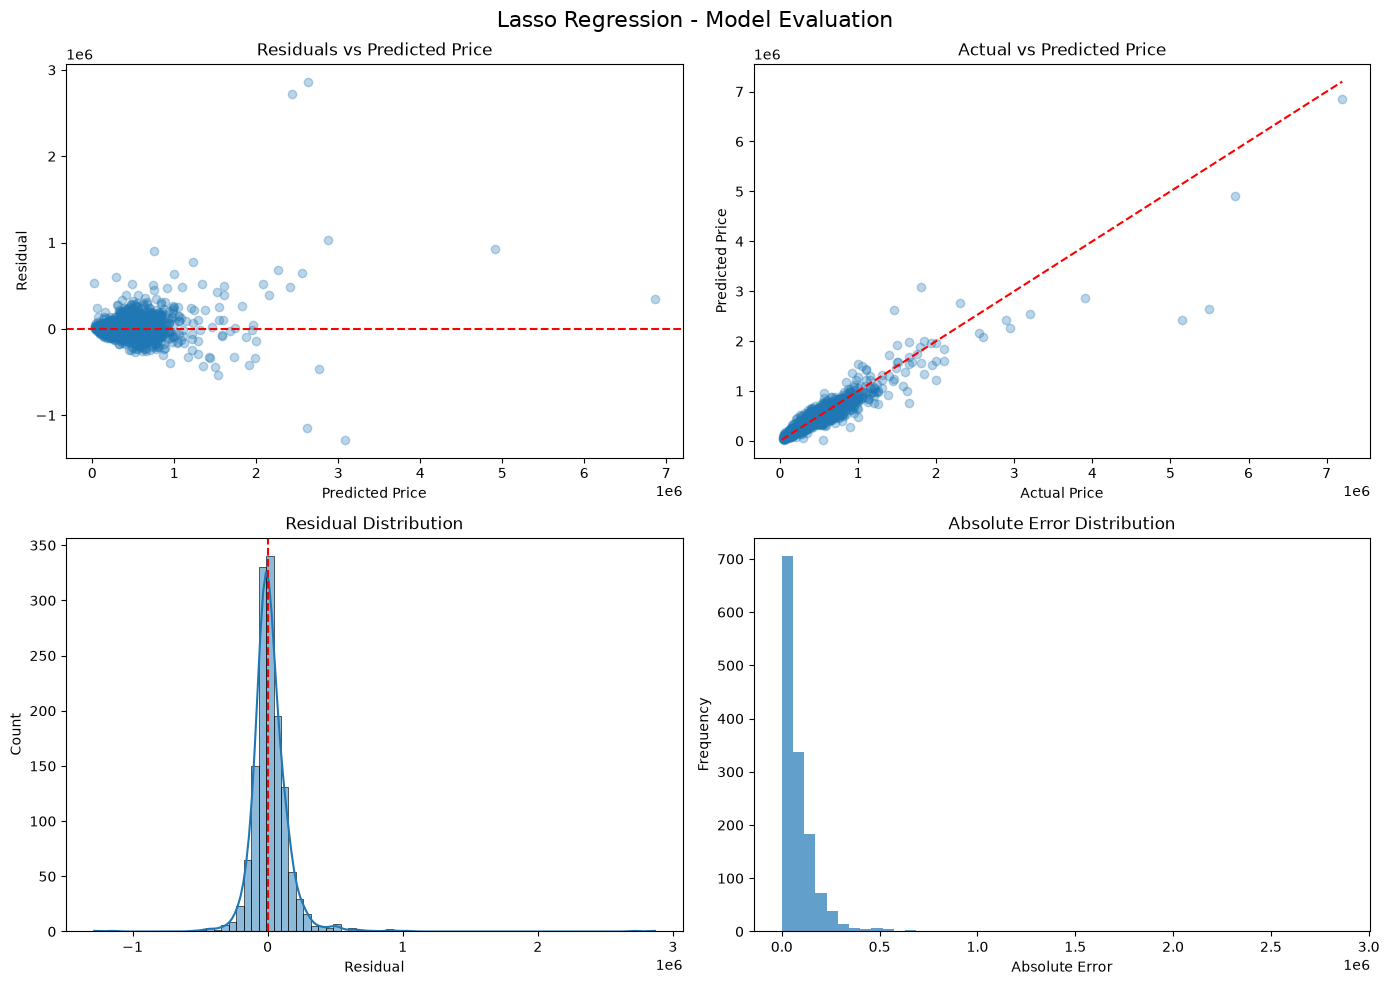


ElasticNet Regression
MAE:  89,298.10
RMSE: 172,268.80
R²:   0.8647

Residual statistics:
count    1.386000e+03
mean     1.866038e+04
std      1.713170e+05
min     -1.263449e+06
25%     -4.738339e+04
50%      4.054215e+02
75%      7.013141e+04
max      2.904949e+06
Name: selling_price, dtype: float64


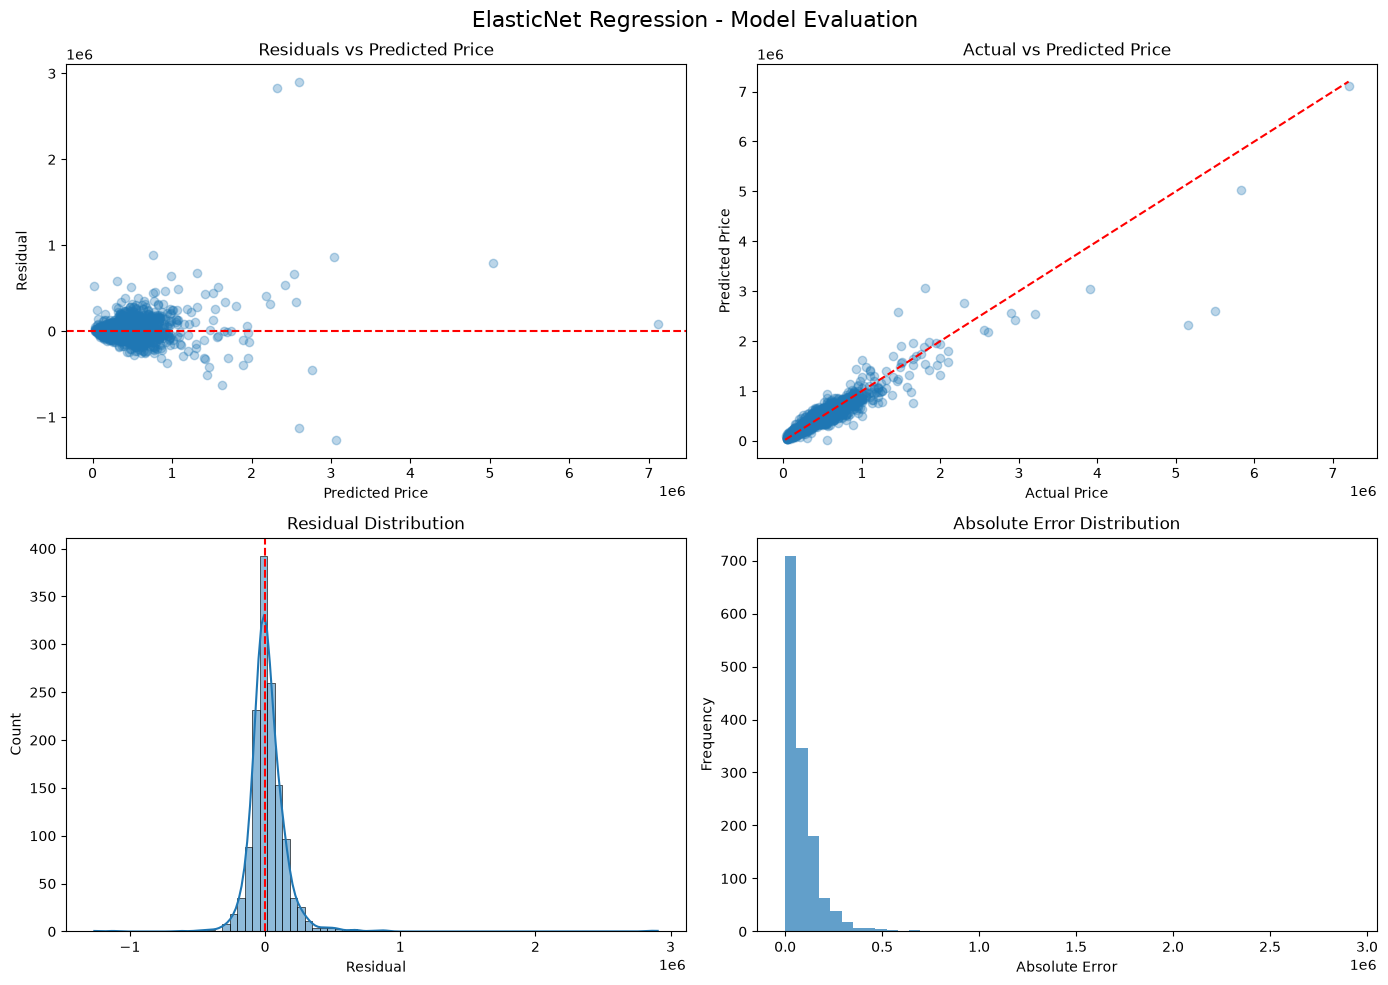


Random Forest
MAE:  70,738.45
RMSE: 122,077.02
R²:   0.9321

Residual statistics:
count    1.386000e+03
mean    -9.794055e+02
std      1.221172e+05
min     -9.947576e+05
25%     -4.693093e+04
50%     -5.357166e+03
75%      4.321616e+04
max      1.616537e+06
Name: selling_price, dtype: float64


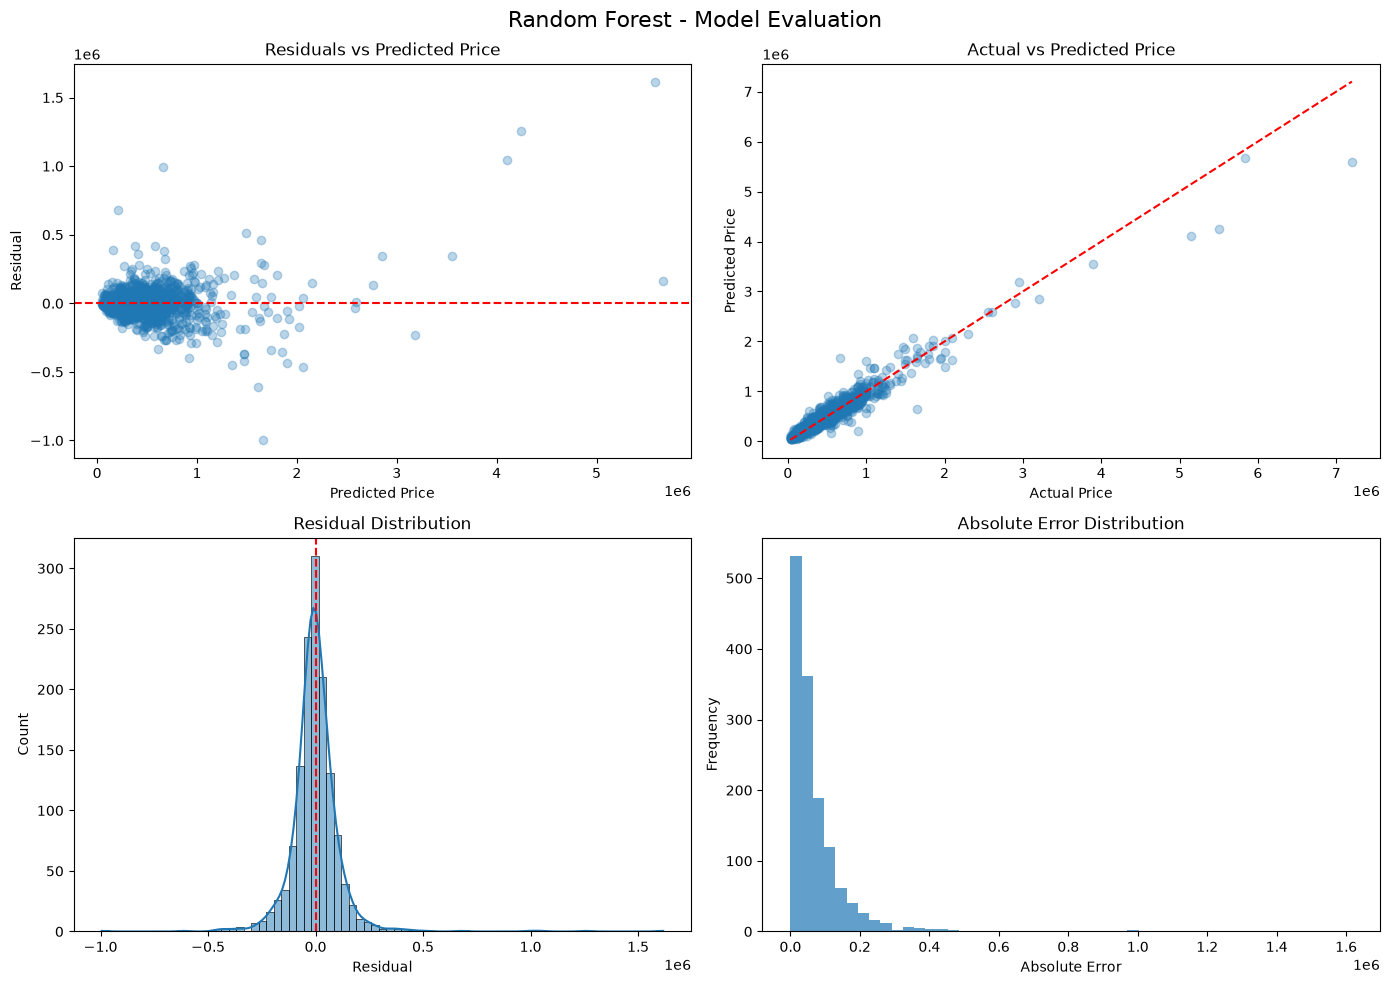


Gradient Boosting
MAE:  77,645.36
RMSE: 127,935.20
R²:   0.9254

Residual statistics:
count    1.386000e+03
mean    -8.471896e+02
std      1.279786e+05
min     -1.162357e+06
25%     -5.534288e+04
50%     -5.685440e+03
75%      4.622756e+04
max      1.413471e+06
Name: selling_price, dtype: float64


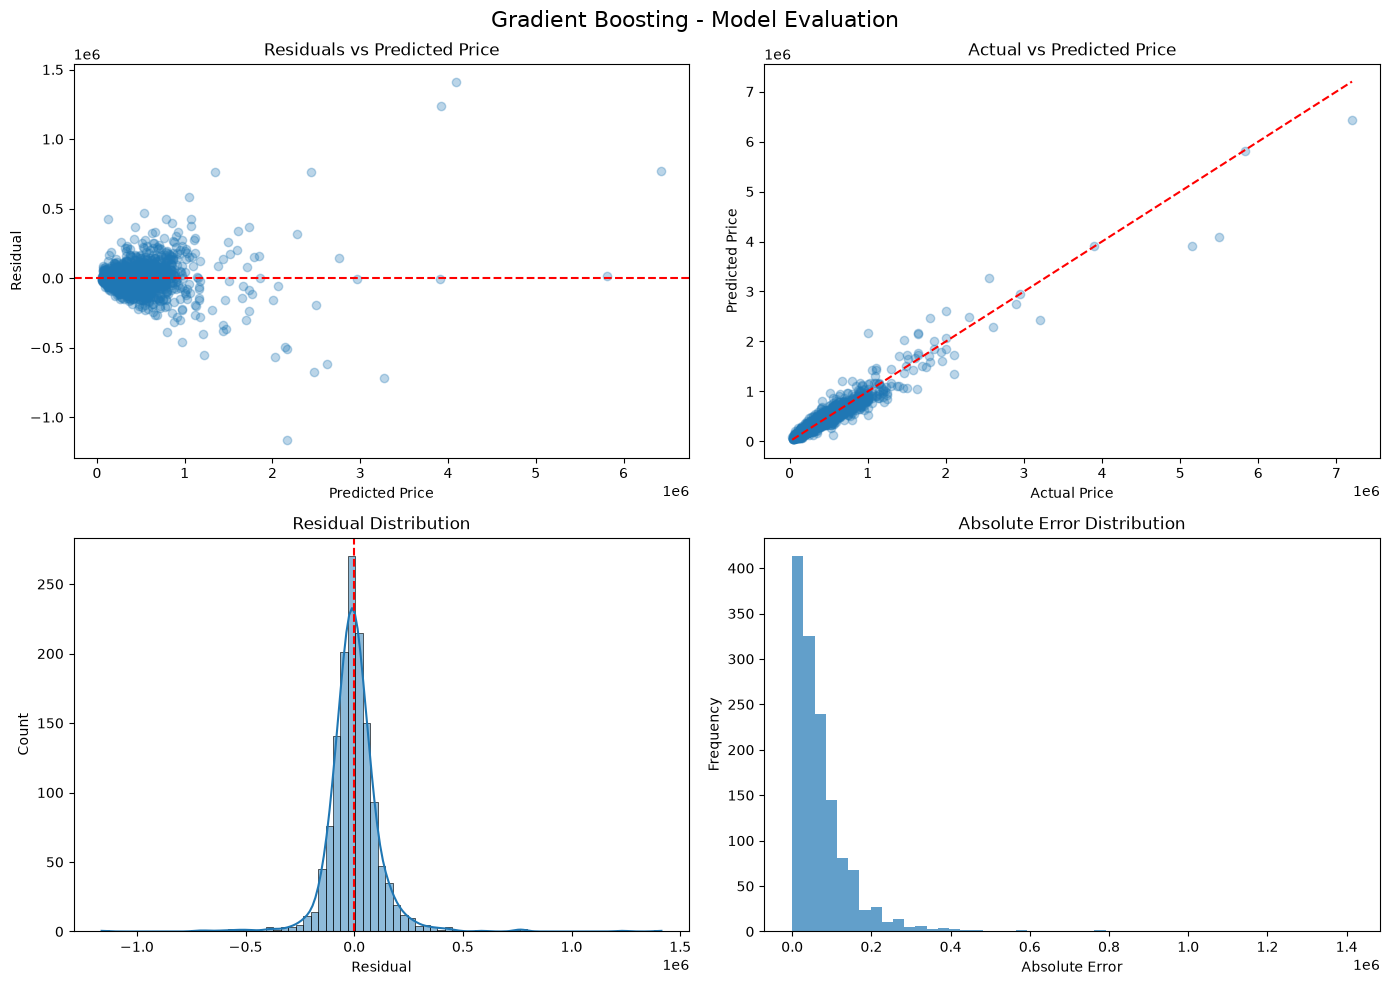

In [21]:
models = {
    "Linear Regression": baseline_model,
    "Ridge Regression": ridge_model,
    "Lasso Regression":lasso_model,
    "ElasticNet Regression":elastic_model,
    'Random Forest':rf_model,
    "Gradient Boosting":gboosting_model,
    
}




def evaluate_model(model, X_test, y_test, model_name):
    
    # Predict
    y_pred_log = model.predict(X_test)
    
    # Convert predictions back to original price scale
    if model_name=='Random Forest' or model_name=='Gradient Boosting' :
        y_pred=y_pred_log
    else:
        y_pred = np.expm1(y_pred_log)
    
    # Residuals
    residuals = y_test - y_pred
    
    # Metrics
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    print(f"\n{'=' * 50}")
    print(f"{model_name}")
    print(f"{'=' * 50}")
    print(f"MAE:  {mae:,.2f}")
    print(f"RMSE: {rmse:,.2f}")
    print(f"R²:   {r2:.4f}")
    
    print("\nResidual statistics:")
    print(pd.Series(residuals).describe())
    
    # Create visualizations
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # 1. Residuals vs predicted
    axes[0, 0].scatter(
        y_pred,
        residuals,
        alpha=0.3
    )
    axes[0, 0].axhline(
        0,
        color="red",
        linestyle="--"
    )
    axes[0, 0].set_xlabel("Predicted Price")
    axes[0, 0].set_ylabel("Residual")
    axes[0, 0].set_title("Residuals vs Predicted Price")
    
    # 2. Actual vs predicted
    axes[0, 1].scatter(
        y_test,
        y_pred,
        alpha=0.3
    )
    
    # Perfect prediction line
    min_value = min(y_test.min(), y_pred.min())
    max_value = max(y_test.max(), y_pred.max())
    
    axes[0, 1].plot(
        [min_value, max_value],
        [min_value, max_value],
        color="red",
        linestyle="--"
    )
    
    axes[0, 1].set_xlabel("Actual Price")
    axes[0, 1].set_ylabel("Predicted Price")
    axes[0, 1].set_title("Actual vs Predicted Price")
    
    # 3. Residual distribution
    sns.histplot(
        residuals,
        kde=True,
        ax=axes[1, 0]
    )
    axes[1, 0].axvline(
        0,
        color="red",
        linestyle="--"
    )
    axes[1, 0].set_xlabel("Residual")
    axes[1, 0].set_title("Residual Distribution")
    
    # 4. Absolute error
    absolute_errors = np.abs(residuals)
    
    axes[1, 1].hist(
        absolute_errors,
        bins=50,
        alpha=0.7
    )
    axes[1, 1].set_xlabel("Absolute Error")
    axes[1, 1].set_ylabel("Frequency")
    axes[1, 1].set_title("Absolute Error Distribution")
    
    plt.suptitle(
        f"{model_name} - Model Evaluation",
        fontsize=16
    )
    
    plt.tight_layout()
    plt.show()
    
    # Return everything so we can reuse it later
    return {
        "model": model_name,
        "predictions": y_pred,
        "residuals": residuals,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }
    
    
results = {}

for name, model in models.items():
    results[name] = evaluate_model(
        model,
        X_test,
        y_test,
        name
    )
    

In [22]:
tuned_pred=rf_model.predict(X_test)

In [23]:
error_df = X_test.copy()

error_df["actual_price"] = y_test.values
error_df["predicted_price"] = tuned_pred

error_df["error"] = (
    error_df["actual_price"]
    - error_df["predicted_price"]
)

error_df["absolute_error"] = (
    error_df["error"].abs()
)

error_df["percentage_error"] = (
    error_df["absolute_error"]
    / error_df["actual_price"]
) * 100

In [24]:
worst_predictions = (
    error_df
    .sort_values("absolute_error", ascending=False)
    .head(20)
)

In [25]:
worst_predictions[
    [
        "brand",
        "year",
        "km_driven",
        "fuel",
        "transmission",
        "owner",
        "actual_price",
        "predicted_price",
        "error",
        "percentage_error",
    ]
]

,brand,year,km_driven,fuel,transmission,owner,actual_price,predicted_price,error,percentage_error
2938,BMW,2020,5000,Diesel,Automatic,First Owner,7200000,5.583463e+06,1.616537e+06,22.451908
7930,Volvo,2019,17000,Diesel,Automatic,First Owner,5500000,4.242748e+06,1.257252e+06,22.859132
132,Lexus,2019,20000,Petrol,Automatic,First Owner,5150000,4.102998e+06,1.047002e+06,20.330128
2137,Land,2013,64788,Diesel,Automatic,First Owner,1650000,6.552233e+05,9.947767e+05,60.289496
4592,Chevrolet,2013,65000,Diesel,Manual,First Owner,667000,1.661758e+06,-9.947576e+05,149.139073
6598,BMW,2008,70000,Diesel,Automatic,Third Owner,890000,2.104979e+05,6.795021e+05,76.348552
4880,BMW,2010,60000,Diesel,Automatic,First Owner,1000000,1.613282e+06,-6.132822e+05,61.328222
6220,Honda,2019,24857,Petrol,Automatic,Test Drive Car,2000000,1.486353e+06,5.136465e+05,25.682327
4030,Toyota,2016,40000,Petrol,Automatic,First Owner,2100000,1.636212e+06,4.637882e+05,22.085154
4380,Skoda,2017,33000,Petrol,Automatic,Second Owner,1600000,2.061750e+06,-4.617496e+05,28.859351


In [26]:
X_train[
    X_train["brand"] == "Land"
].head(20)

,year,km_driven,fuel,seller_type,transmission,owner,mileage,seats,engine_cc,max_power_bhp,torque_nm,torque_rpm_min,torque_rpm_max,vehicle_age,km_per_year,power_per_cc,brand
135,2019,21000,Diesel,Dealer,Automatic,First Owner,12.83,7.0,1999,148.31,382.0,1750.0,2250.0,1,21000.000000,0.074192,Land
6724,2013,77500,Diesel,Individual,Automatic,Third Owner,12.7,5.0,2179,187.7,420.0,2000.0,2000.0,7,11071.428571,0.08614,Land


In [27]:
error_df["price_range"] = pd.cut(
    error_df["actual_price"],
    bins=[
        0,
        200_000,
        500_000,
        1_000_000,
        2_000_000,
        float("inf"),
    ],
    labels=[
        "<200K",
        "200K-500K",
        "500K-1M",
        "1M-2M",
        ">2M",
    ],
)

In [28]:
error_by_range = (
    error_df
    .groupby("price_range", observed=True)
    .agg(
        MAE=("absolute_error", "mean"),
        RMSE=("error", lambda x: np.sqrt(np.mean(x**2))),
        Count=("error", "size"),
    )
)

error_by_range

,MAE,RMSE,Count
price_range,,,
<200K,38623.393390,51620.705016,276
200K-500K,53274.256148,72039.099820,595
500K-1M,85730.855742,127404.471409,435
1M-2M,187371.693678,241371.907095,67
>2M,449109.757927,671832.637443,13


In [29]:


kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_predictions = cross_val_predict(
    rf_model,
    X_train,
    y_train,
    cv=kf,
    n_jobs=-1
)



In [30]:
cv_mae = mean_absolute_error(y_train, cv_predictions)
cv_rmse = np.sqrt(
    mean_squared_error(y_train, cv_predictions)
)
cv_r2 = r2_score(y_train, cv_predictions)

print("CV MAE:", cv_mae)
print("CV RMSE:", cv_rmse)
print("CV R²:", cv_r2)

CV MAE: 81647.10821264847
CV RMSE: 178756.95118674755
CV R²: 0.886983678605967


In [31]:
from sklearn.model_selection import cross_validate

cv_results = cross_validate(
    rf_model,
    X_train,
    y_train,
    cv=kf,
    scoring={
        "r2": "r2",
        "rmse": "neg_root_mean_squared_error",
    },
    n_jobs=-1,
)

print("R² per fold:", cv_results["test_r2"])
print(
    "RMSE per fold:",
    -cv_results["test_rmse"]
)

R² per fold: [0.90569858 0.91517893 0.88558263 0.89372108 0.8211219 ]
RMSE per fold: [190402.09244729 167720.67729027 162598.86106556 142582.67860226
 220496.81569511]


In [32]:
print("X_train Shape",X_train.shape)
print("X_test Shape",X_test.shape)
print("y_train Shape",y_train.shape)
print("y_test Shape",y_test.shape)


X_train Shape (5540, 17)
X_test Shape (1386, 17)
y_train Shape (5540,)
y_test Shape (1386,)


In [33]:
rf = rf_model.named_steps["model"]

In [34]:
feature_names = (
    rf_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

In [35]:
importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": rf.feature_importances_
})

importance_df = (
    importance_df
    .sort_values("importance", ascending=False)
)
print(importance_df.head(20))

                                feature  importance
5                numeric__max_power_bhp    0.541603
0                         numeric__year    0.112086
9                  numeric__vehicle_age    0.105141
6                    numeric__torque_nm    0.090172
1                    numeric__km_driven    0.038110
11                numeric__power_per_cc    0.021831
2                      numeric__mileage    0.020414
10                 numeric__km_per_year    0.008533
8               numeric__torque_rpm_max    0.007411
4                    numeric__engine_cc    0.006698
53            categorical__brand_Toyota    0.005404
7               numeric__torque_rpm_min    0.005259
45     categorical__brand_Mercedes-Benz    0.005156
3                        numeric__seats    0.003751
52              categorical__brand_Tata    0.003680
41              categorical__brand_Land    0.002763
28               categorical__brand_BMW    0.002760
21       categorical__owner_First Owner    0.002117
19  categori

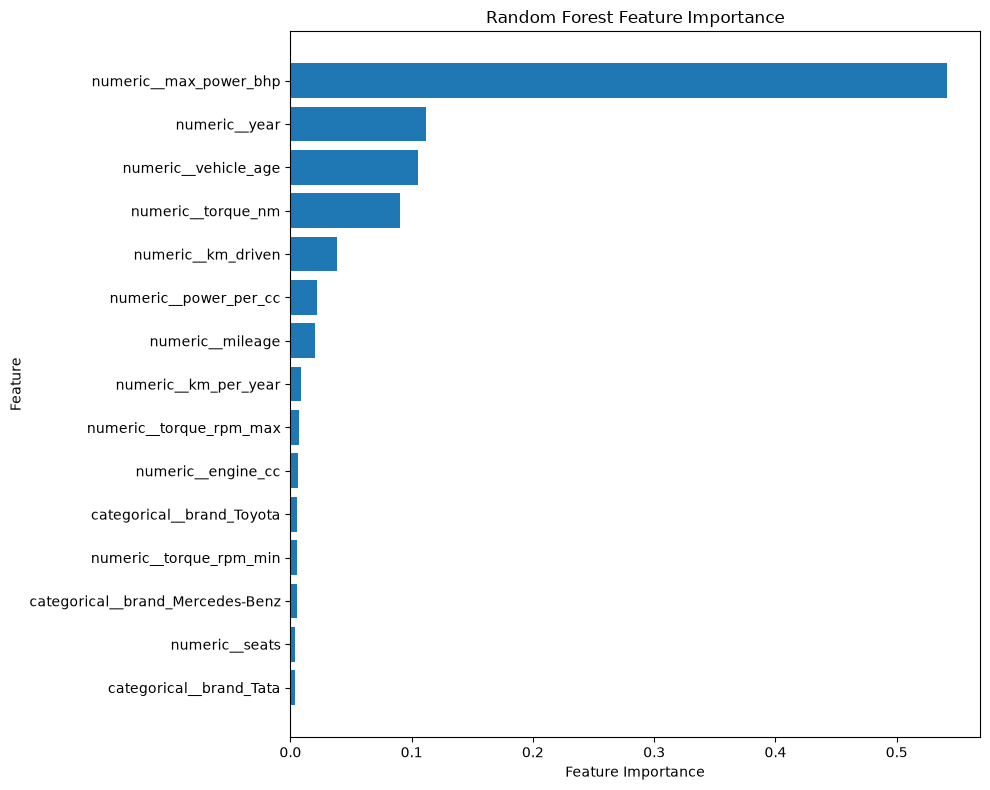

In [36]:
plt.figure(figsize=(10, 8))

top_features = importance_df.head(15).sort_values("importance")

plt.barh(
    top_features["feature"],
    top_features["importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.tight_layout()
plt.show()

## SHAP `Features Contribution Analysis`

In [37]:
import shap

f:\ML_PROJECTS\used-car-price-prediction\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [38]:
X_shap = X_train.sample(
    500,
    random_state=42
)

In [39]:
rf_preprocessor=rf_model.named_steps['preprocessor']
rf=rf_model.named_steps['model']
X_shap_transformed=rf_preprocessor.transform(X_shap)
feature_names=rf_preprocessor.get_feature_names_out()

In [40]:
explainer=shap.TreeExplainer(rf)

In [43]:
shap_values=explainer.shap_values(X_shap_transformed)

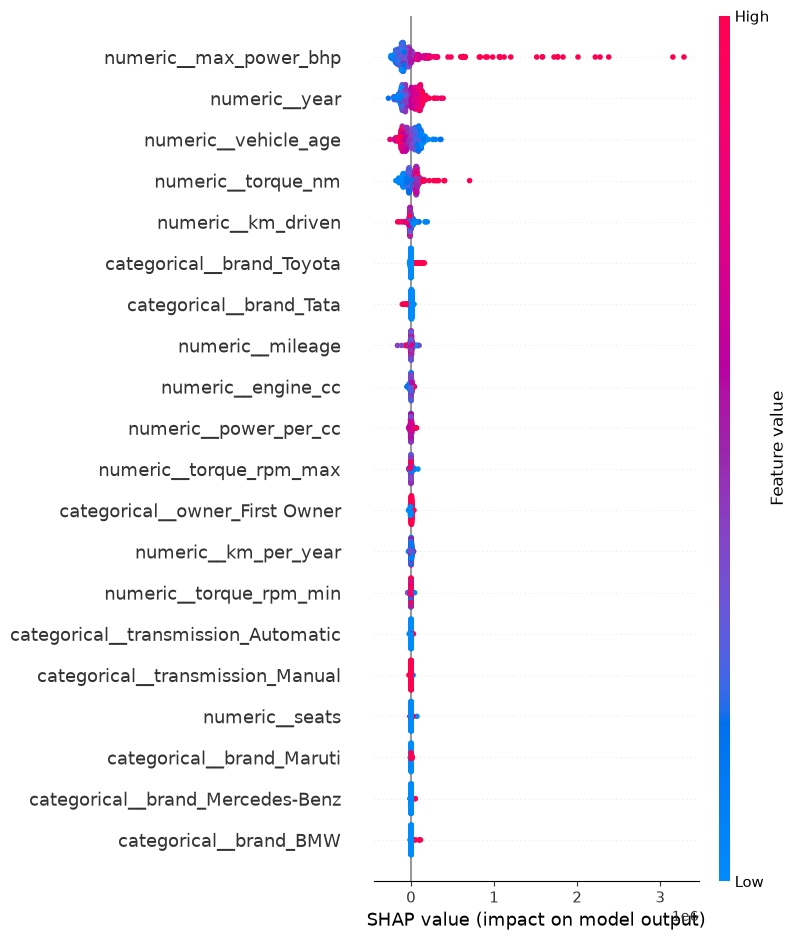

In [44]:
shap.summary_plot(
    shap_values,
    X_shap_transformed,
    feature_names=feature_names
)

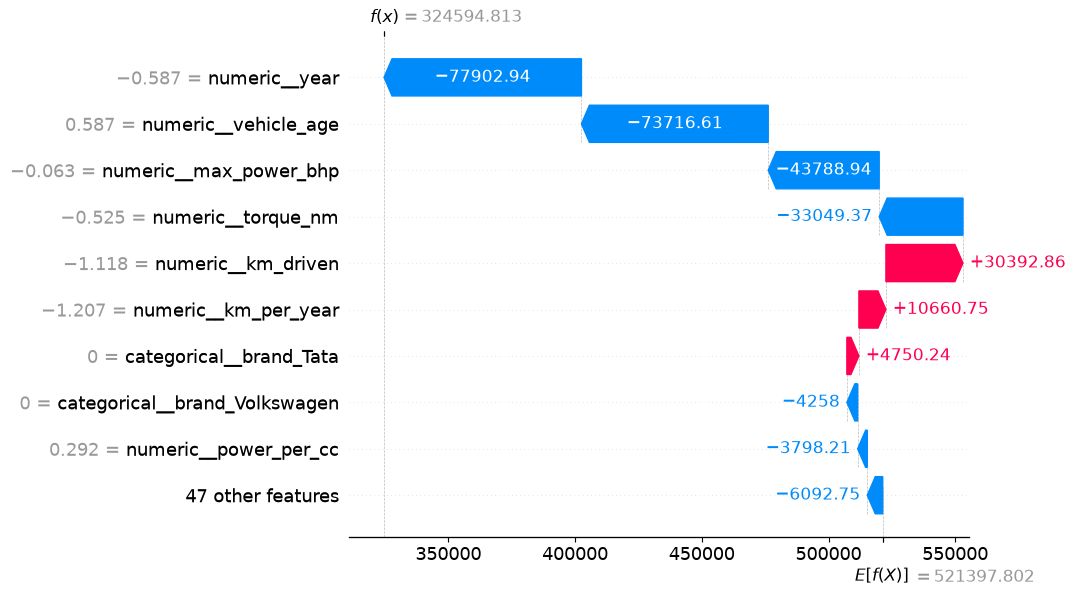

In [49]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[1],
        base_values=explainer.expected_value[0],
        data=X_shap_transformed[1],
        feature_names=feature_names
    )
)

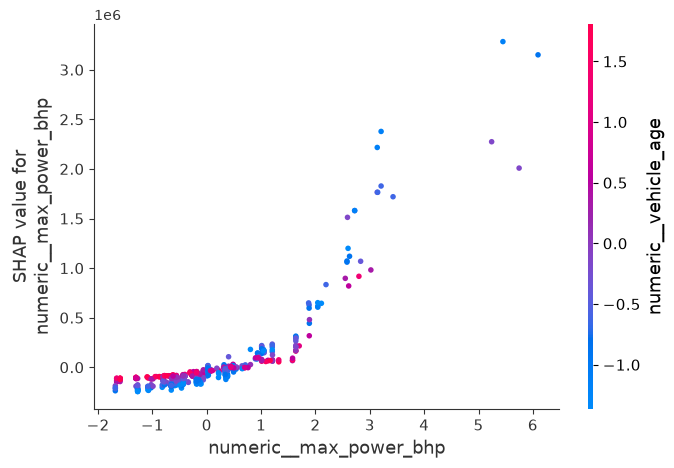

In [50]:
shap.dependence_plot(
    "numeric__max_power_bhp",
    shap_values,
    X_shap_transformed,
    feature_names=feature_names
)